# Phase 1 : Classical Acoustic Baseline

## Objective

Build the first machine-fault detection baseline using simple
time-domain acoustic features and a classical machine-learning model.

For the initial experiment:

- Machine: Fan
- Machine ID: id_00
- Acoustic condition: 0 dB
- Classes: Normal / Abnormal
- One complete 10-second recording = one ML sample

The goal is to determine whether simple acoustic measurements contain
enough information to distinguish normal and abnormal machine operation.

In [1]:
import numpy as np 
import pandas as pd 
import librosa

In [2]:
def extract_features(audio_path):
    y, sr = librosa.load(audio_path, sr = None)

    features = {
        'RMS':librosa.feature.rms(y=y).mean(),
        'STD':np.std(y),
        'Variance':np.var(y),
        'ZCR':librosa.feature.zero_crossing_rate(y).mean(),
        'Peak':np.max(np.abs(y))
    }

    return features

In [3]:
audio_path = 'C:/Users/Deep/Desktop/Deep/Projects/Acoustic machine fault detection/acoustic-machine-fault-detection/data/raw/fan/id_00/normal/00000000.wav'
extract_features(audio_path)

{'RMS': np.float32(0.0061088228),
 'STD': np.float32(0.00615511),
 'Variance': np.float32(3.788538e-05),
 'ZCR': np.float64(0.05407597843450479),
 'Peak': np.float32(0.025714874)}

In [4]:
audio_path = 'C:/Users/Deep/Desktop/Deep/Projects/Acoustic machine fault detection/acoustic-machine-fault-detection/data/raw/fan/id_00/abnormal/00000000.wav'
extract_features(audio_path)

{'RMS': np.float32(0.009899851),
 'STD': np.float32(0.009975875),
 'Variance': np.float32(9.951808e-05),
 'ZCR': np.float64(0.033508885782747605),
 'Peak': np.float32(0.03604889)}

##  Build the Feature Dataset

We apply the baseline feature extractor to all available recordings.

Each row represents one complete 10-second recording.

Features:
- RMS
- Standard deviation
- Variance
- Zero-crossing rate
- Peak amplitude

The target variable is the machine condition:
- normal = 0
- abnormal = 1

In [5]:
from pathlib import Path
import pandas as pd

data_root = Path('C:/Users/Deep/Desktop/Deep/Projects/Acoustic machine fault detection/acoustic-machine-fault-detection/data/raw/fan/id_00')

records = []

for label,target in [('normal',0),('abnormal',1)]:
    folder = data_root/label

    for audio_file in sorted(folder.glob('*.wav')):
        features = extract_features(audio_file)

        records.append({
            'file':audio_file.name,
            'label':label,
            'target':target,
            **features
        })

df = pd.DataFrame(records)

print('Number of recordings: ',len(df))
print('\nClass distribution: ')
print(df['label'].value_counts())
df.head()

Number of recordings:  160

Class distribution: 
label
normal      80
abnormal    80
Name: count, dtype: int64


,file,label,target,RMS,STD,Variance,ZCR,Peak
0,00000000.wav,normal,0,0.006109,0.006155,0.000038,0.054076,0.025715
1,00000001.wav,normal,0,0.006047,0.006093,0.000037,0.058666,0.024212
2,00000002.wav,normal,0,0.006098,0.006158,0.000038,0.078609,0.028824
3,00000003.wav,normal,0,0.005885,0.005935,0.000035,0.071381,0.025776
4,00000004.wav,normal,0,0.005820,0.005914,0.000035,0.071702,0.036419


In [6]:
df.groupby('label')[['RMS','STD','ZCR','Variance','Peak']].mean()

,RMS,STD,ZCR,Variance,Peak
label,,,,,
abnormal,0.009724,0.009794,0.033748,0.000096,0.035194
normal,0.005861,0.005911,0.070487,0.000035,0.026158


In [7]:
import matplotlib.pyplot as plt


def plot_feature(df, feature):
    normal = df[df['label']=='normal'][feature]
    abnormal = df[df['label']=='abnormal'][feature]

    plt.figure(figsize = (8,5))

    plt.hist(normal, bins=20, alpha=0.6, label="Normal")
    plt.hist(abnormal, bins=20, alpha=0.6, label="Abnormal")

    plt.xlabel(feature)
    plt.ylabel("Number of recordings")
    plt.title(f"{feature} distribution: normal vs abnormal")
    plt.legend()
    plt.show()

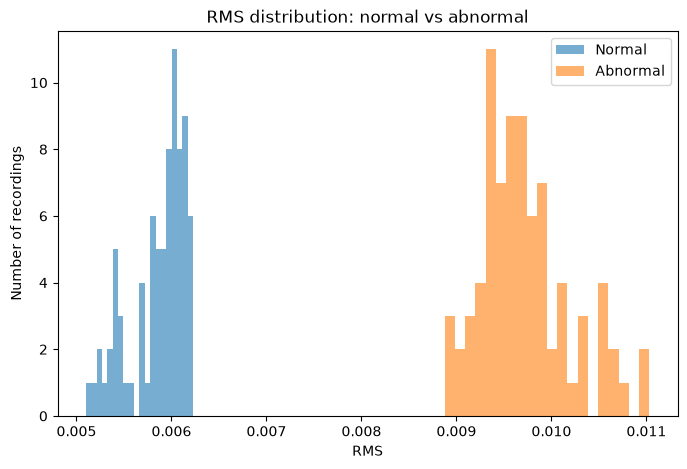

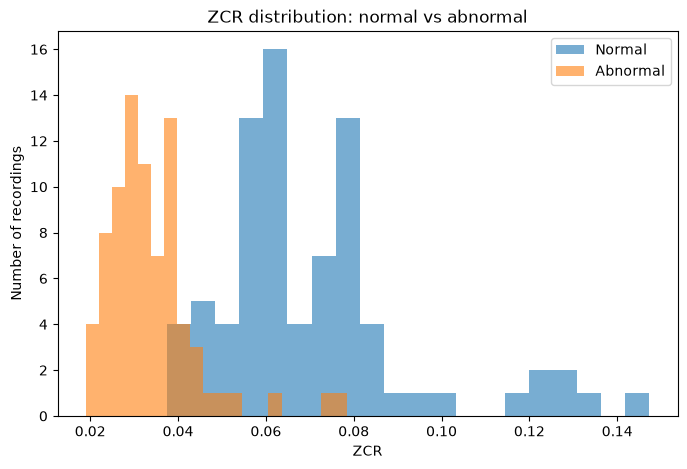

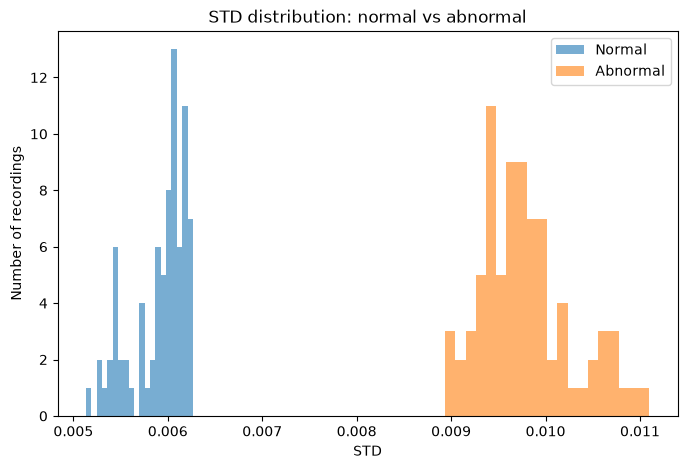

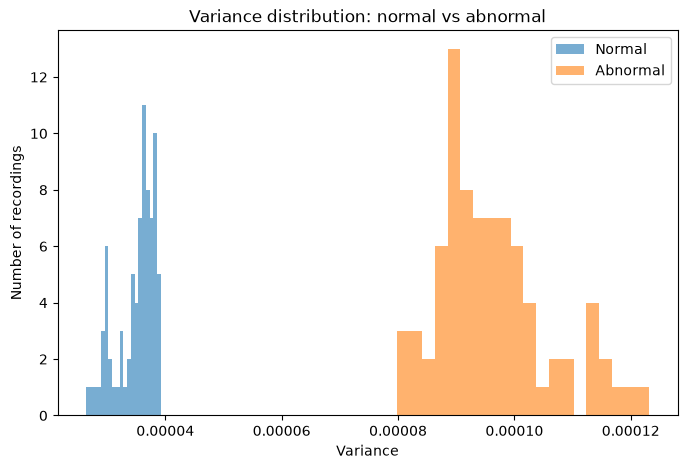

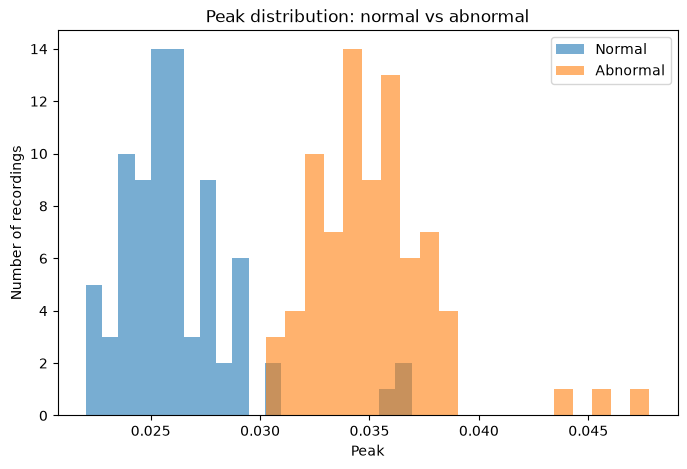

In [8]:
plot_feature(df,'RMS')
plot_feature(df, 'ZCR')
plot_feature(df, 'STD')
plot_feature(df, 'Variance')
plot_feature(df, 'Peak')

In [9]:
feature_col = ['RMS','STD','Variance','ZCR','Peak']
correlation_matrix = df[feature_col].corr()
print(correlation_matrix)

               RMS       STD  Variance       ZCR      Peak
RMS       1.000000  0.999921  0.998421 -0.783311  0.860931
STD       0.999921  1.000000  0.998594 -0.783705  0.864003
Variance  0.998421  0.998594  1.000000 -0.769022  0.864345
ZCR      -0.783311 -0.783705 -0.769022  1.000000 -0.656618
Peak      0.860931  0.864003  0.864345 -0.656618  1.000000


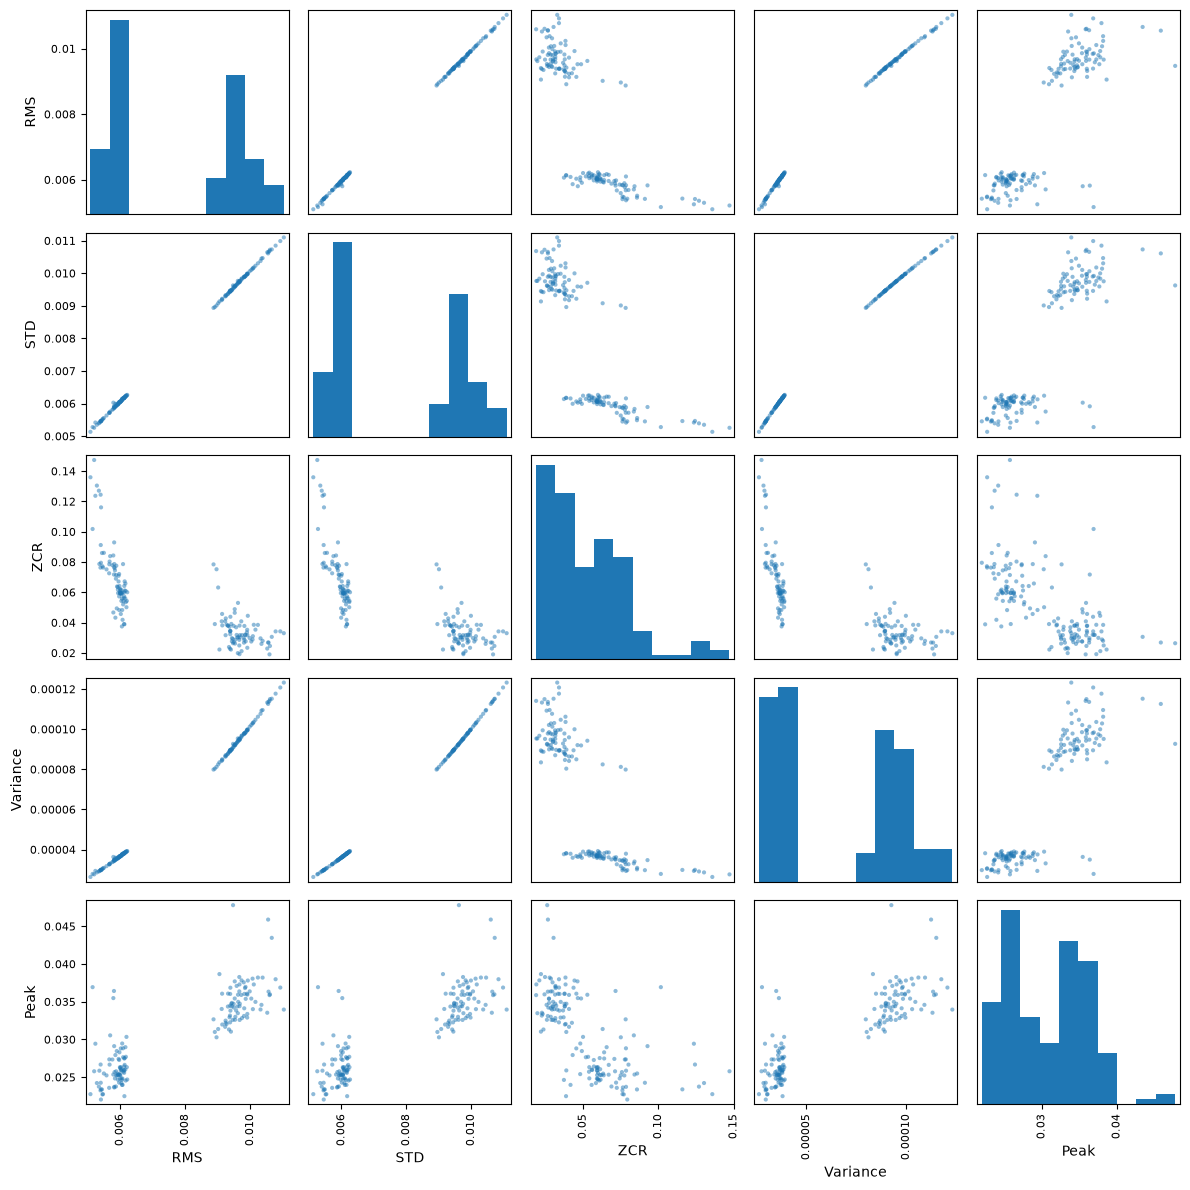

In [10]:
pd.plotting.scatter_matrix(
    df[['RMS','STD','ZCR','Variance','Peak']],
    figsize = [12,12],
    diagonal = 'hist'
)

plt.tight_layout()
plt.show()

## Feature Sets for the Baseline Model

Two feature sets are evaluated:

### Full feature set
RMS, STD, Variance, ZCR, Peak

### Reduced feature set
RMS, ZCR, Peak

The reduced set removes features that are highly correlated with
RMS and therefore may provide largely redundant information.

We will compare their performance using the same train/test split
and the same classifier.

## First Classical ML Baseline

We now test whether the acoustic features can be used by a simple
classical machine-learning classifier.

The first model is Logistic Regression.

The initial feature set contains RMS, ZCR and Peak. Standard deviation
and variance are omitted because they are highly correlated with RMS
in this dataset.

The data will be divided into training and test sets before fitting
the model.

In [11]:
from sklearn.model_selection import train_test_split

X = df[['RMS','ZCR','Peak']]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state= 42,
    stratify = y
)

print('Training samples: ',len(X_train))
print('Test samples: ',len(X_test))

Training samples:  128
Test samples:  32


## Logistic Regression Baseline

We use Logistic Regression as the first classifier because it provides a
simple and interpretable baseline for the binary normal/abnormal task.

The model learns a relationship between the acoustic features and the
probability that a recording belongs to the abnormal class.

In [12]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(y_pred)

[0 1 0 0 0 1 1 1 0 0 1 0 1 1 1 0 1 0 1 1 0 1 0 1 1 1 0 0 1 1 0 0]


In [13]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print('Test accuracy: ',accuracy)

Test accuracy:  0.90625


## Model Evaluation

Accuracy alone does not describe the type of errors made by the
classifier. We therefore examine the confusion matrix and calculate
precision, recall and F1-score.

[[14  2]
 [ 1 15]]


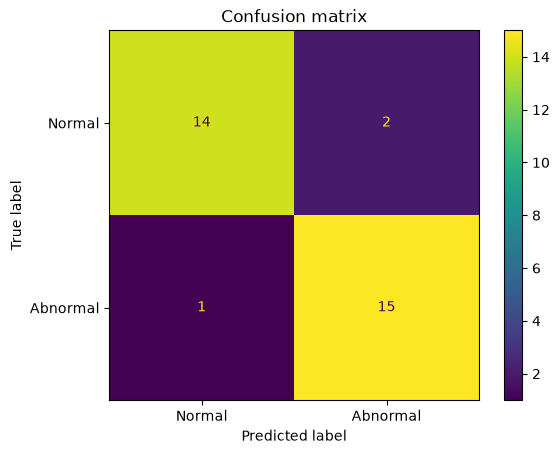

In [14]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = ['Normal','Abnormal']
)

disp.plot()
plt.title("Confusion matrix")
plt.show()

In [15]:
from sklearn.metrics import classification_report
print(classification_report(
    y_test,
    y_pred,
    target_names=['Normal','Abnormal']
))

              precision    recall  f1-score   support

      Normal       0.93      0.88      0.90        16
    Abnormal       0.88      0.94      0.91        16

    accuracy                           0.91        32
   macro avg       0.91      0.91      0.91        32
weighted avg       0.91      0.91      0.91        32



In [16]:
results = X_test.copy()
results['actual'] = y_test
results['predicted'] = y_pred

errors = results[results['actual']!=results['predicted']]
print(errors)

          RMS       ZCR      Peak  actual  predicted
120  0.008875  0.078414  0.032661       1          0
29   0.005906  0.049343  0.028458       0          1
21   0.006084  0.041822  0.023975       0          1


In [17]:
error_indices = [120,29,21]
df.loc[error_indices,['file','label','RMS','ZCR','Peak']]

,file,label,RMS,ZCR,Peak
120,00000040.wav,abnormal,0.008875,0.078414,0.032661
29,00000029.wav,normal,0.005906,0.049343,0.028458
21,00000021.wav,normal,0.006084,0.041822,0.023975


In [18]:
normal_df = df[df['label'] == 'normal'].copy()
abnormal_df = df[df['label'] == 'abnormal'].copy()

normal_median_rms = normal_df['RMS'].median()
abnormal_median_rms = abnormal_df['RMS'].median()

normal_example = normal_df.loc[(normal_df['RMS'] - normal_median_rms).abs().idxmin()]
abnormal_example = abnormal_df.loc[(abnormal_df['RMS'] - abnormal_median_rms).abs().idxmin()]

missed_abnormal = df.loc[120]

print('Representative normal: ',normal_example['RMS'])
print('Representative abnormal: ',abnormal_example['RMS'])
print('Missed abnormal: ',missed_abnormal['RMS'])

Representative normal:  0.00596032
Representative abnormal:  0.009631178
Missed abnormal:  0.008874912


In [19]:
print('feature coefficients: ')

for feature,coefficient in zip(X.columns, model.coef_[0]):
    print(feature,' : ',coefficient)

print('\nintercept: ',model.intercept_[0])

feature coefficients: 
RMS  :  0.12256786887133952
ZCR  :  -1.20306458151728
Peak  :  0.28546486734557885

intercept:  0.05329332297833658


## End-to-End Inference

The trained baseline is converted into an inference function that accepts
a raw WAV file, extracts the same acoustic features used during training,
and produces a normal/abnormal prediction.

In [20]:
def predict_audio(audio_path, model):
    features = extract_features(audio_path)
    X_new = pd.DataFrame([{
        'RMS':features['RMS'],
        'ZCR':features['ZCR'],
        'Peak':features['Peak']
        }])

    prediction = model.predict(X_new)[0]
    probability = model.predict_proba(X_new)[0,1]

    if prediction == 1:
        label = 'abnormal'
    else:
        label = 'normal'

    return label, probability

In [21]:
test_index = X_test.index[0]
test_row = df.loc[test_index]

test_path = (f"C:/Users/Deep/Desktop/Deep/Projects/Acoustic machine fault detection/acoustic-machine-fault-detection/data/raw/fan/id_00/{test_row['label']}/{test_row['file']}")

print('File: ',test_path)
print('Actual: ',test_row['label'])

label, probability = predict_audio(test_path, model)

print('Predicted: ',label)
print(f'Abnormal probability: {probability: .3f}')

File:  C:/Users/Deep/Desktop/Deep/Projects/Acoustic machine fault detection/acoustic-machine-fault-detection/data/raw/fan/id_00/abnormal/00000040.wav
Actual:  abnormal
Predicted:  normal
Abnormal probability:  0.492


In [22]:
inference_results = []

for index in X_test.index:
    row = df.loc[index]
    audio_path = (f"C:/Users/Deep/Desktop/Deep/Projects/Acoustic machine fault detection/acoustic-machine-fault-detection/data/raw/fan/id_00/{row['label']}/{row['file']}")
    label, probability = predict_audio(audio_path, model)

    inference_results.append({
        'index':index,
        'file':row['file'],
        'actual':row['label'],
        'predicted':label,
        'abnormal_probability':probability
    }
    )

inference = pd.DataFrame(inference_results)
print("number of inference samples: ",len(inference))
print(inference.head())

original_pred = pd.Series(y_pred, index = X_test.index)

inference_pred = inference.set_index('index')['predicted'].map({'normal':0,'abnormal':1})

print('predictions identical: ',original_pred.equals(inference_pred))

print(inference[inference['actual']!=inference['predicted']])

number of inference samples:  32
   index          file    actual predicted  abnormal_probability
0    120  00000040.wav  abnormal    normal              0.492343
1     90  00000010.wav  abnormal  abnormal              0.510495
2     60  00000060.wav    normal    normal              0.494450
3     23  00000023.wav    normal    normal              0.497513
4     20  00000020.wav    normal    normal              0.499845
predictions identical:  True
    index          file    actual predicted  abnormal_probability
0     120  00000040.wav  abnormal    normal              0.492343
12     29  00000029.wav    normal  abnormal              0.500695
29     21  00000021.wav    normal  abnormal              0.502642


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
scaled_model = LogisticRegression()
scaled_model.fit(X_train_scaled, y_train)
y_pred_scaled = scaled_model.predict(X_test_scaled)

original_accuracy = accuracy_score(y_test, y_pred)
scaled_accuracy = accuracy_score(y_test, y_pred_scaled)

print("Original accuracy: ", original_accuracy)
print("Scaled accuraccy: ",scaled_accuracy)

Original accuracy:  0.90625
Scaled accuraccy:  1.0


In [25]:
print(confusion_matrix(y_test, y_pred_scaled))
print(
    classification_report(
        y_test,
        y_pred_scaled,
        target_names = ['normal','abnormal']
    )
)

[[16  0]
 [ 0 16]]
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00        16
    abnormal       1.00      1.00      1.00        16

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32



In [26]:
from sklearn.pipeline import Pipeline

final_model = Pipeline([
    ('scaler',StandardScaler()),
    ('classifier',LogisticRegression())
])

final_model.fit(X_train, y_train)
y_pred_final = final_model.predict(X_test)

print('Test accuracy: ',accuracy_score(y_test, y_pred_final))

Test accuracy:  1.0


In [27]:
inference_results = []

for index in X_test.index:
    row = df.loc[index]
    audio_path = (f"C:/Users/Deep/Desktop/Deep/Projects/Acoustic machine fault detection/acoustic-machine-fault-detection/data/raw/fan/id_00/{row['label']}/{row['file']}")
    label, probability = predict_audio(audio_path, final_model)

    inference_results.append({
        'index':index,
        'file':row['file'],
        'actual':row['label'],
        'predicted':label,
        'abnormal_probability':probability
    }
    )

inference = pd.DataFrame(inference_results)
print("number of inference samples: ",len(inference))
print(inference.head())

original_pred = pd.Series(y_pred_final, index = X_test.index)

inference_pred = inference.set_index('index')['predicted'].map({'normal':0,'abnormal':1})

print('predictions identical: ',original_pred.equals(inference_pred))

print(inference[inference['actual']!=inference['predicted']])

number of inference samples:  32
   index          file    actual predicted  abnormal_probability
0    120  00000040.wav  abnormal  abnormal              0.762468
1     90  00000010.wav  abnormal  abnormal              0.997799
2     60  00000060.wav    normal    normal              0.009067
3     23  00000023.wav    normal    normal              0.025099
4     20  00000020.wav    normal    normal              0.048639
predictions identical:  True
Empty DataFrame
Columns: [index, file, actual, predicted, abnormal_probability]
Index: []


 Phase 1 : Baseline Results

A classical machine-learning baseline was developed using acoustic
time-domain features extracted from MIMII fan recordings.

### Dataset
- Machine: Fan
- Machine ID: id_00
- Condition: 0 dB
- 160 recordings
- 80 normal / 80 abnormal
- 10 seconds per recording
- Sampling rate: 16 kHz

### Features
- RMS
- Zero-crossing rate
- Peak amplitude

Standard deviation and variance were excluded from the final feature
set because they were highly correlated with RMS in this dataset.

### Model
StandardScaler + Logistic Regression

### Evaluation
- Train/test split: 80/20
- Stratified split
- Random state: 42
- Test samples: 32

### Result
Test accuracy: 100%

Confusion matrix:

[[16, 0],
 [ 0,16]]

The model correctly classified all 32 held-out recordings.

### Limitation
This result was obtained on a controlled subset consisting of a single
fan machine instance (id_00) under one acoustic condition (0 dB).
Therefore, the result does not establish generalization to other
machines, machine types, or operating/environmental conditions.